# 제품명 키워드 빈도 · 워드클라우드 실험

**작성일:** 2026-05-26

`runs/` 아래 `normalized.json`의 상품명(`product` / `product_clean`)을 카테고리별로 토큰화하고, 빈도 분석 후 워드클라우드로 시각화합니다.

목적: 브랜드 컨셉·시장 트렌드·디자인 패턴 키워드 검출 가능성을 탐색하는 1차 실험입니다.

## 사전 준비

프로젝트 루트에서 venv 활성화 후 노트북 의존성을 설치합니다.

```bash
source .venv/bin/activate
pip install wordcloud matplotlib pandas jupyter
```

In [1]:
from __future__ import annotations

import json
import re
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from wordcloud import WordCloud

# 프로젝트 루트 (notebooks/ 의 부모)
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RUNS_DIR = PROJECT_ROOT / "runs"
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "output" / "product_name_wordcloud"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# None이면 normalized.json이 있는 run 중 이름(타임스탬프)이 가장 최신인 디렉터리 사용
RUN_DIR: Path | None = None

# '000000'(전체)는 세부 카테고리와 중복되므로 워드클라우드 대상에서 제외
SKIP_CATEGORY_CODES = {"000000"}

MIN_TOKEN_LEN = 2
TOP_N_TABLE = 30
WORDCLOUD_MAX_WORDS = 120

In [2]:
def list_run_dirs(runs_dir: Path) -> list[Path]:
    """normalized.json 수정 시각 기준 최신순."""
    candidates = []
    for path in runs_dir.iterdir():
        if not path.is_dir():
            continue
        norm = path / "normalized.json"
        if norm.is_file():
            candidates.append(path)
    return sorted(candidates, key=lambda p: (p / "normalized.json").stat().st_mtime, reverse=True)


def resolve_run_dir(runs_dir: Path, run_dir: Path | None) -> Path:
    if run_dir is not None:
        run_dir = run_dir.resolve()
        if not (run_dir / "normalized.json").is_file():
            raise FileNotFoundError(f"normalized.json 없음: {run_dir}")
        return run_dir
    runs = list_run_dirs(runs_dir)
    if not runs:
        raise FileNotFoundError(f"{runs_dir} 아래에 normalized.json이 있는 run이 없습니다.")
    return runs[0]  # mtime 최신


def load_items(run_dir: Path) -> list[dict]:
    path = run_dir / "normalized.json"
    with path.open(encoding="utf-8") as f:
        payload = json.load(f)
    items = payload.get("items", [])
    if not isinstance(items, list):
        raise ValueError("normalized.json: items가 리스트가 아닙니다.")
    return items


run_dir = resolve_run_dir(RUNS_DIR, RUN_DIR)
items = load_items(run_dir)
print(f"run: {run_dir.name}")
print(f"items: {len(items):,}")

run: 20260526_165724
items: 13,752


## 토큰화 · 포괄 단어 필터

상품명은 한·영 혼용이 많아 형태소 분석기 없이 **구분자 분할 + 한글 연속 구간 / 영문 단어 추출** 방식을 사용합니다.

트렌드·디자인 신호만 남기려면 아래 3단계로 **포괄적 상품군 명사**를 걸러냅니다.

| 단계 | 방식 | 예 |
|------|------|----|
| 1. 수동 사전 | `GENERIC_GARMENT_STOPWORDS` | 티셔츠, pants, bag |
| 2. 카테고리 앵커 | 랭킹 카테고리 라벨·카테고리별 사전 | 가방(004000), 바지(003000) |
| 3. 자동(교차 출현) | N개 카테고리에 고르게 많이 나오는 토큰 | 여러 분류에 공통인 상위어 |

유지 예: 니트, 반팔, 크롭, 윈드브레이커, 와이드 — 실루엣·소재·디테일에 가까운 표현

In [3]:
# 색상·옵션·SKU 등 의미 없는 노이즈
NOISE_STOPWORDS = frozenset({
    "color", "colors", "colour", "colours",
    "size", "sizes", "option", "options",
    "the", "and", "for", "with", "men", "women", "unisex",
    "new", "ver", "edition", "set", "pack",
    "블랙", "화이트", "블루", "레드", "그린", "베이지", "그레이", "브라운", "핑크",
    "black", "white", "blue", "red", "green", "beige", "gray", "grey", "brown", "pink",
})

# 상품군·포괄 분류어 (디테일/트렌드 분석 시 제거) — 필요 시 자유롭게 추가
GENERIC_GARMENT_STOPWORDS = frozenset({
    "티셔츠", "티", "셔츠", "tee", "tshirt", "tshirts", "shirt", "shirts",
    "팬츠", "pants", "pant", "trousers", "trouser", "jeans", "진",
    "bag", "bags", "백", "가방", "백팩", "backpack", "숄더백", "토트백", "토트", "tote",
    "신발", "shoes", "shoe", "스니커즈", "sneakers", "sneaker",
    "스커트", "skirt", "skirts", "드레스", "dress", "dresses", "원피스",
    "모자", "cap", "caps", "hat", "hats",
    "양말", "삭스", "socks", "sock",
    "상의", "하의", "아우터", "outer", "의류", "패션",
    "acc", "accessory", "accessories", "악세서리", "액세서리",
})

# 카테고리 컨텍스트에서만 제거할 포괄어 (다른 카테고리에서는 신호일 수 있음)
CATEGORY_GENERIC_STOPWORDS: dict[str, frozenset[str]] = {
    "001000": frozenset({"상의", "top", "tops", "맨투맨"}),
    "002000": frozenset({"아우터", "outer", "재킷", "jacket", "jackets", "coat", "coats"}),
    "003000": frozenset({"바지", "bottom", "bottoms"}),
    "004000": frozenset({"bag", "bags", "가방", "백", "백팩", "backpack"}),
}

FILTER_GENERIC_TOKENS = True
AUTO_FILTER_UBIQUITOUS = True
UBIQUITOUS_MIN_CATEGORY_RATIO = 0.75  # 활성 카테고리의 75% 이상에 등장
UBIQUITOUS_MIN_COUNT_PER_CATEGORY = 25

STOPWORDS = NOISE_STOPWORDS  # tokenize 단계에서 제거

_HANGUL = re.compile(r"[가-힣]{2,}")
_ENGLISH = re.compile(r"[A-Za-z][A-Za-z0-9]*")
_PURE_ASCII_SKU = re.compile(r"^[A-Z0-9][A-Z0-9:\-]{5,}$")
_SPLIT = re.compile(r"[\s\[\]\(\)_\-/·,:]+")


def product_display_name(item: dict) -> str:
    name = (item.get("product_clean") or item.get("product") or "").strip()
    return name


def label_anchor_tokens(label: str) -> frozenset[str]:
    """카테고리 라벨 자체(예: 바지, 가방)를 해당 카테고리 포괄어로 취급."""
    anchors: set[str] = set()
    for m in _HANGUL.finditer(label):
        if len(m.group()) >= MIN_TOKEN_LEN:
            anchors.add(m.group())
    for m in _ENGLISH.finditer(label):
        w = m.group().lower()
        if len(w) >= MIN_TOKEN_LEN:
            anchors.add(w)
    return frozenset(anchors)


def discover_ubiquitous_tokens(
    raw_by_cat: dict[tuple[str, str], Counter],
    *,
    min_category_ratio: float = UBIQUITOUS_MIN_CATEGORY_RATIO,
    min_count_per_category: int = UBIQUITOUS_MIN_COUNT_PER_CATEGORY,
) -> frozenset[str]:
    """여러 카테고리에 고르게 많이 나오는 토큰 = 구조적 포괄어 후보."""
    if not raw_by_cat:
        return frozenset()
    n_cats = len(raw_by_cat)
    need = max(2, int(n_cats * min_category_ratio + 0.999))
    token_cat_hits: dict[str, int] = defaultdict(int)
    for ctr in raw_by_cat.values():
        for tok, count in ctr.items():
            if count >= min_count_per_category:
                token_cat_hits[tok] += 1
    return frozenset(tok for tok, hits in token_cat_hits.items() if hits >= need)


def generic_stopwords_for(
    category_code: str,
    category_label: str,
    ubiquitous: frozenset[str] | None = None,
) -> frozenset[str]:
    code = str(category_code)
    words = set(GENERIC_GARMENT_STOPWORDS)
    words |= CATEGORY_GENERIC_STOPWORDS.get(code, frozenset())
    words |= label_anchor_tokens(category_label)
    if ubiquitous:
        words |= ubiquitous if isinstance(ubiquitous, (set, frozenset)) else frozenset(ubiquitous)
    return frozenset(words)


def tokenize_product_name(name: str) -> list[str]:
    if not name:
        return []
    tokens: list[str] = []
    for chunk in _SPLIT.split(name):
        chunk = chunk.strip()
        if not chunk or len(chunk) < MIN_TOKEN_LEN:
            continue
        if _PURE_ASCII_SKU.match(chunk):
            continue
        for m in _HANGUL.finditer(chunk):
            w = m.group()
            if w not in STOPWORDS:
                tokens.append(w)
        for m in _ENGLISH.finditer(chunk):
            w = m.group().lower()
            if len(w) >= MIN_TOKEN_LEN and w not in STOPWORDS:
                tokens.append(w)
    return tokens


# 샘플: 필터 전 / 후 (상의 카테고리 기준)
_demo_code, _demo_label = "001000", "상의"
_demo_stop = generic_stopwords_for(_demo_code, _demo_label)
samples = [product_display_name(it) for it in items if product_display_name(it)][:5]
for s in samples:
    raw = tokenize_product_name(s)
    kept = [t for t in raw if t not in _demo_stop]
    print(s)
    print("  raw:", raw)
    print("  kept (상의):", kept)

[크롭] 배색 롤업 크롭 반팔 티셔츠_블랙
  raw: ['크롭', '배색', '롤업', '크롭', '반팔', '티셔츠']
  kept (상의): ['크롭', '배색', '롤업', '크롭', '반팔']
[UV 프로텍션] 우먼즈 시어 윈드브레이커 (5 colors)
  raw: ['uv', '프로텍션', '우먼즈', '시어', '윈드브레이커']
  kept (상의): ['uv', '프로텍션', '우먼즈', '시어', '윈드브레이커']
[여름용] VLAD 원턱 커브드 트랙 팬츠_립스탑 3 COLOR
  raw: ['여름용', 'vlad', '원턱', '커브드', '트랙', '팬츠', '립스탑']
  kept (상의): ['여름용', 'vlad', '원턱', '커브드', '트랙', '립스탑']
라이크 에어 시프트 백팩 (BLACK)
  raw: ['라이크', '에어', '시프트', '백팩']
  kept (상의): ['라이크', '에어', '시프트']
[크롭] 배색 롤업 크롭 반팔 티셔츠_버건디
  raw: ['크롭', '배색', '롤업', '크롭', '반팔', '티셔츠', '버건디']
  kept (상의): ['크롭', '배색', '롤업', '크롭', '반팔', '버건디']


In [4]:
def category_key(item: dict) -> tuple[str, str]:
    code = str(item.get("category_code") or item.get("category_major_code") or "")
    label = str(item.get("category_label") or item.get("category_parent_label") or code)
    return code, label


def build_category_counters(
    items: list[dict],
    *,
    filter_generic: bool = FILTER_GENERIC_TOKENS,
    auto_ubiquitous: bool = AUTO_FILTER_UBIQUITOUS,
) -> tuple[dict[tuple[str, str], Counter], frozenset[str]]:
    raw_by_cat: dict[tuple[str, str], Counter] = defaultdict(Counter)
    skipped_no_name = 0
    for item in items:
        code, label = category_key(item)
        if code in SKIP_CATEGORY_CODES:
            continue
        name = product_display_name(item)
        if not name:
            skipped_no_name += 1
            continue
        for tok in tokenize_product_name(name):
            raw_by_cat[(code, label)][tok] += 1

    ubiquitous: frozenset[str] = frozenset()
    if filter_generic and auto_ubiquitous:
        ubiquitous = discover_ubiquitous_tokens(raw_by_cat)

    by_cat: dict[tuple[str, str], Counter] = {}
    removed_total = 0
    for key, ctr in raw_by_cat.items():
        code, label = key
        if filter_generic:
            stop = generic_stopwords_for(code, label, ubiquitous)
            filtered = Counter({t: c for t, c in ctr.items() if t not in stop})
            removed_total += sum(ctr.values()) - sum(filtered.values())
            by_cat[key] = filtered
        else:
            by_cat[key] = ctr

    print(
        f"카테고리 수: {len(by_cat)}, 상품명 없음 스킵: {skipped_no_name}, "
        f"포괄어 필터: {'ON' if filter_generic else 'OFF'}, "
        f"자동(교차출현): {len(ubiquitous)}개, 제거 토큰 occurrence: {removed_total:,}"
    )
    if ubiquitous:
        print("  자동 제거 예:", sorted(ubiquitous)[:20])
    return by_cat, ubiquitous


category_counters, ubiquitous_tokens = build_category_counters(items)
summary_rows = []
for (code, label), ctr in sorted(category_counters.items(), key=lambda x: (-sum(x[1].values()), x[0][0])):
    summary_rows.append({
        "category_code": code,
        "category_label": label,
        "token_occurrences": sum(ctr.values()),
        "unique_tokens": len(ctr),
    })
pd.DataFrame(summary_rows)

카테고리 수: 4, 상품명 없음 스킵: 0, 포괄어 필터: ON, 자동(교차출현): 16개, 제거 토큰 occurrence: 11,089
  자동 제거 예: ['navy', '나일론', '네이비', '린넨', '벨티드', '빈티지', '시티', '썸머', '에센셜', '우먼즈', '저지', '컬러', '코튼', '쿨탠다드', '크롭', '하프']


,category_code,category_label,token_occurrences,unique_tokens
0,003000,바지,11914,863
1,002000,아우터,11699,1047
2,001000,상의,10130,892
3,004000,가방,8369,1159


## 카테고리별 TOP 키워드

In [5]:
def top_terms_table(counter: Counter, n: int = TOP_N_TABLE) -> pd.DataFrame:
    rows = [{"token": t, "count": c} for t, c in counter.most_common(n)]
    return pd.DataFrame(rows)


for (code, label), ctr in sorted(category_counters.items(), key=lambda x: x[0][0]):
    print(f"\n=== {label} ({code}) — TOP {TOP_N_TABLE} ===")
    display(top_terms_table(ctr))
    out_csv = OUTPUT_DIR / f"{run_dir.name}_{code}_top_tokens.csv"
    top_terms_table(ctr).to_csv(out_csv, index=False, encoding="utf-8-sig")


=== 상의 (001000) — TOP 30 ===


,token,count
0,반팔,811
1,헨리넥,258
2,니트,256
3,폴로,243
4,오버핏,196
5,반팔티,171
6,롤업,158
7,워셔블,150
8,스트라이프,141
9,차콜,129



=== 아우터 (002000) — TOP 30 ===


,token,count
0,윈드브레이커,450
1,블레이저,406
2,가디건,390
3,시어,354
4,자켓,292
5,후드,254
6,레저,248
7,트랙탑,246
8,라이트,188
9,셋업,179



=== 바지 (003000) — TOP 30 ===


,token,count
0,와이드,1034
1,밴딩,475
2,데님,446
3,버뮤다,364
4,슬랙스,335
5,커브드,305
6,스웨트,259
7,원턱,258
8,히든,244
9,쇼츠,209



=== 가방 (004000) — TOP 30 ===


,token,count
0,in,188
1,레더,171
2,인치,170
3,미니,167
4,캐리어,131
5,크로스백,108
6,mini,105
7,호보,81
8,shoulder,79
9,dot,77


## 워드클라우드

한글 렌더링: WordCloud `font_path` + matplotlib `rcParams`/`fontproperties`에 동일 폰트를 적용합니다. 다른 OS에서는 `FONT_CANDIDATES`에 경로를 추가하세요.

In [6]:
import matplotlib.font_manager as fm

# matplotlib는 .ttf가 .ttc보다 안정적 → WordCloud·제목 공용 폰트 후보
FONT_CANDIDATES = [
    "/System/Library/Fonts/Supplemental/AppleGothic.ttf",
    "/System/Library/Fonts/AppleSDGothicNeo.ttc",
    "/Library/Fonts/Arial Unicode.ttf",
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
]


def resolve_font_path() -> str | None:
    for path in FONT_CANDIDATES:
        if Path(path).is_file():
            return path
    return None


def configure_matplotlib_korean(font_path: str | None) -> fm.FontProperties | None:
    """워드클라우드 제목·캡션 등 matplotlib 텍스트에 한글 폰트 적용."""
    if not font_path:
        return None
    try:
        fm.fontManager.addfont(font_path)
    except (ValueError, OSError):
        pass  # 이미 등록됨 또는 TTC 중복 등록
    prop = fm.FontProperties(fname=font_path)
    family = prop.get_name()
    plt.rcParams["font.family"] = family
    plt.rcParams["font.sans-serif"] = [family, "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False
    return prop


FONT_PATH = resolve_font_path()
MPL_FONT = configure_matplotlib_korean(FONT_PATH)
if FONT_PATH and MPL_FONT:
    print(f"font: {FONT_PATH} (matplotlib: {MPL_FONT.get_name()})")
else:
    print("경고: 한글 폰트를 찾지 못했습니다. 제목·워드클라우드 한글이 깨질 수 있습니다.")

font: /System/Library/Fonts/Supplemental/AppleGothic.ttf (matplotlib: AppleGothic)


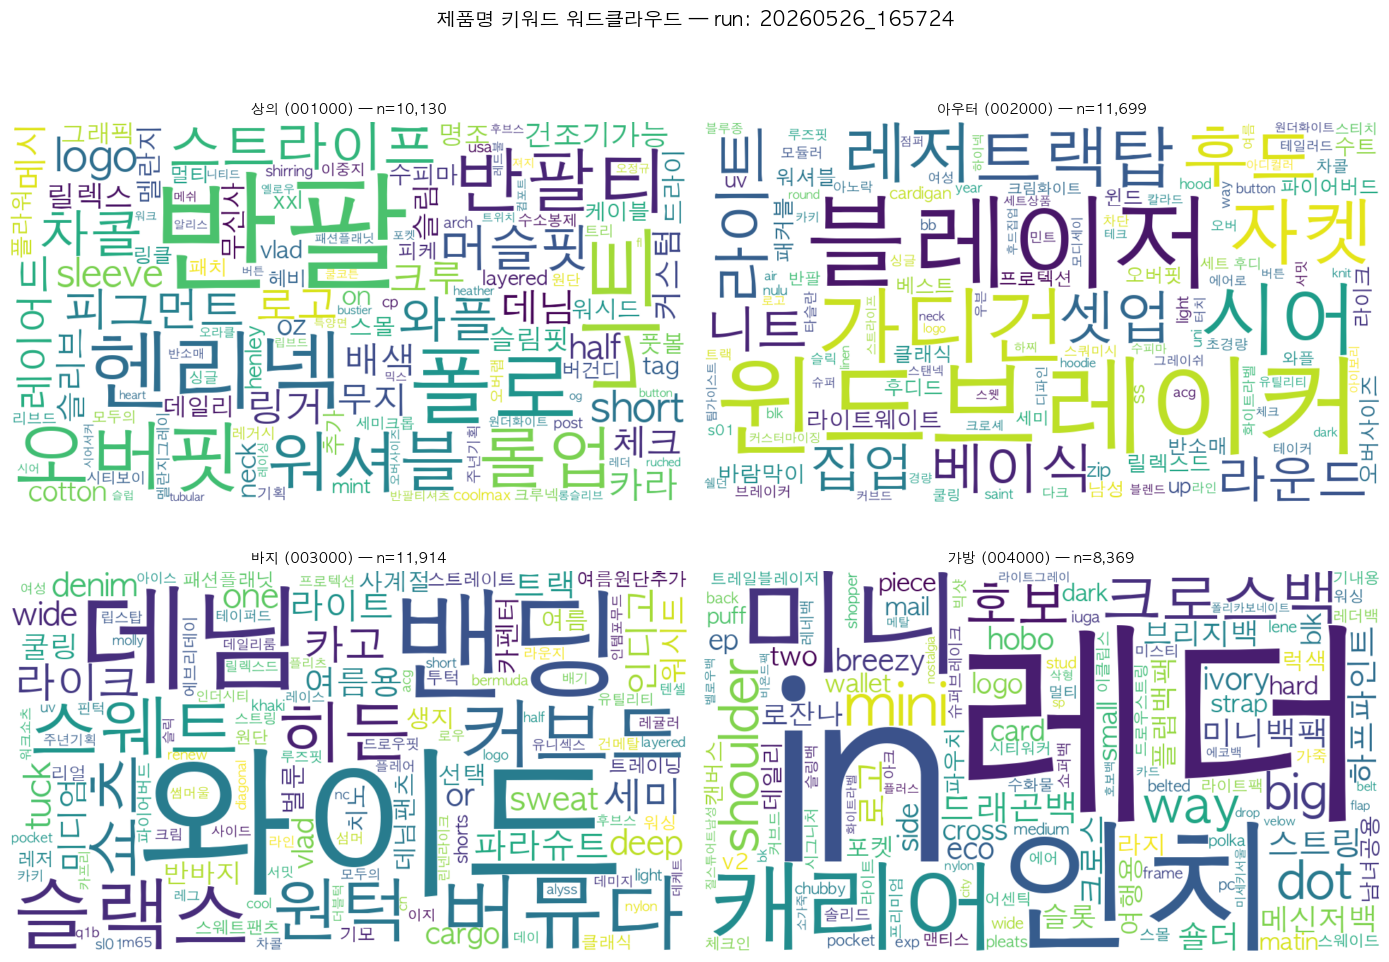

저장: /Users/bhc/dev/datadrift/v1/datadrift_app_engine/v2/silhouette_outliner/notebooks/output/product_name_wordcloud


In [7]:
def make_wordcloud(counter: Counter, title: str) -> WordCloud:
    freq = dict(counter.most_common(WORDCLOUD_MAX_WORDS))
    kwargs = dict(
        width=960,
        height=540,
        background_color="white",
        max_words=WORDCLOUD_MAX_WORDS,
        colormap="viridis",
        prefer_horizontal=0.85,
    )
    if FONT_PATH:
        kwargs["font_path"] = FONT_PATH
    # generate_from_frequencies가 레이아웃까지 계산함 (wordcloud 1.9+: layout_는 속성)
    return WordCloud(**kwargs).generate_from_frequencies(freq)


n_cats = len(category_counters)
ncols = 2
nrows = (n_cats + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
axes_flat = axes.flatten() if n_cats > 1 else [axes]

_title_font = {"fontproperties": MPL_FONT} if MPL_FONT else {}

for ax, ((code, label), ctr) in zip(axes_flat, sorted(category_counters.items(), key=lambda x: x[0][0])):
    wc = make_wordcloud(ctr, label)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"{label} ({code}) — n={sum(ctr.values()):,}", **_title_font)
    ax.axis("off")
    png_path = OUTPUT_DIR / f"{run_dir.name}_{code}_wordcloud.png"
    wc.to_file(str(png_path))

for ax in axes_flat[len(category_counters):]:
    ax.axis("off")

fig.suptitle(
    f"제품명 키워드 워드클라우드 — run: {run_dir.name}",
    fontsize=14,
    y=1.01,
    **_title_font,
)
plt.tight_layout()
overview_path = OUTPUT_DIR / f"{run_dir.name}_wordcloud_overview.png"
fig.savefig(overview_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"저장: {OUTPUT_DIR}")